In [ ]:
# =====================================
# 1. Import Libraries
# =====================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

# =====================================
# 2. Load Dataset
# =====================================
df = pd.read_excel("/content/EV_Similar_Dataset project.xlsx")

# =====================================
# 3. Explore Dataset
# =====================================
print("Columns List:")
print(df.columns.to_list())

print("\nFirst 5 Rows:")
print(df.head())

# =====================================
# 4. Handle Categorical Columns
# =====================================
le = LabelEncoder()

categorical_cols = ["Make", "Model", "Vehicle_Class", "Transmission", "Fuel_Type"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# =====================================
# 5. Feature Selection
# =====================================
# Target variable: SOH (State of Health)
X = df.drop(columns=["SOH"])
y = df["SOH"]

# =====================================
# 6. Train-Test Split
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================
# 7. Initialize Models
# =====================================
rf = RandomForestRegressor()
lr = LinearRegression()
dt = DecisionTreeRegressor()
xgb = XGBRegressor()

# =====================================
# 8. Train Models
# =====================================
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# =====================================
# 9. Predictions
# =====================================
rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
xgb_pred = xgb.predict(X_test)

# =====================================
# 10. Evaluation Function
# =====================================
def evaluate(name, y_test, pred):
    print(f"\n{name} Results:")
    print("MAE:", mean_absolute_error(y_test, pred))
    print("MSE:", mean_squared_error(y_test, pred))
    print("R2 Score:", r2_score(y_test, pred))

# =====================================
# 11. Evaluate All Models
# =====================================
evaluate("Random Forest", y_test, rf_pred)
evaluate("Linear Regression", y_test, lr_pred)
evaluate("Decision Tree", y_test, dt_pred)
evaluate("XGBoost", y_test, xgb_pred)

# =====================================
# 12. GridSearchCV (Random Forest Tuning)
# =====================================
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

best_rf = grid.best_estimator_
best_pred = best_rf.predict(X_test)

evaluate("Tuned Random Forest", y_test, best_pred)

# =====================================
# 13. Voting Regressor (Hybrid Model)
# =====================================
voting = VotingRegressor(
    estimators=[
        ('rf', rf),
        ('lr', lr),
        ('dt', dt)
    ]
)

voting.fit(X_train, y_train)
voting_pred = voting.predict(X_test)

evaluate("Voting Regressor", y_test, voting_pred)

# =====================================
# 14. Final Accuracy (R2 Score)
# =====================================
print("\nFinal Accuracy (R2 Score of Voting Model):",
      r2_score(y_test, voting_pred))

Columns List:
['Model_Year', 'Make', 'Model', 'Vehicle_Class', 'Motor_(kW)', 'Transmission', 'Fuel_Type', 'Range_(km)', 'terminal_voltage', 'terminal_current', 'temperature', 'charge_current', 'charge_voltage', 'time', 'capacity', 'cycle', 'SOH']

First 5 Rows:
   Model_Year        Make           Model Vehicle_Class  Motor_(kW)  \
0        2017  Volkswagen  Focus Electric    SUV: Small         102   
1        2021  Volkswagen  Focus Electric    SUV: Small         284   
2        2021      Nissan         Model S    Subcompact         130   
3        2021       Volvo  Focus Electric      Mid-size          54   
4        2023  Mitsubishi          i-MiEV       Compact         192   

  Transmission Fuel_Type  Range_(km)  terminal_voltage  terminal_current  \
0           A1         B         447          3.832652         -2.293314   
1           A1         B         119          3.848976          1.281984   
2           A1         B         176          3.525474         -2.209174   
3      

In [ ]:
get_ipython().run_line_magic('matplotlib', 'inline')
import os

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import random
import pickle

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

import warnings
warnings.simplefilter("ignore")

In [ ]:
df = pd.read_excel(r"/content/EV_Similar_Dataset project.xlsx")
df


,Model_Year,Make,Model,Vehicle_Class,Motor_(kW),Transmission,Fuel_Type,Range_(km),terminal_voltage,terminal_current,temperature,charge_current,charge_voltage,time,capacity,cycle,SOH
0,2017,Volkswagen,Focus Electric,SUV: Small,102,A1,B,447,3.832652,-2.293314,32.101563,0.0235,4.009,412.429,1.619294,14,0.810325
1,2021,Volkswagen,Focus Electric,SUV: Small,284,A1,B,119,3.848976,1.281984,44.659498,0.5474,4.163,437.016,1.700050,110,0.745218
2,2021,Nissan,Model S,Subcompact,130,A1,B,176,3.525474,-2.209174,40.112061,1.3117,3.330,274.804,1.901334,26,0.798493
3,2021,Volvo,Focus Electric,Mid-size,54,A1,B,304,3.717614,2.276002,39.693230,0.1610,3.741,708.535,1.919843,152,0.662463
4,2023,Mitsubishi,i-MiEV,Compact,192,A1,B,177,3.818936,0.204734,30.015846,1.3009,4.088,816.811,1.619550,102,0.790951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2019,Volkswagen,Model S,Mid-size,271,A1,B,123,3.532419,1.080998,40.244766,0.8560,2.667,353.502,1.467555,117,0.892067
296,2020,Ford,Focus Electric,Compact,177,A1,B,303,3.642742,0.411827,38.696516,0.1512,3.687,322.581,1.907499,96,0.761031
297,2021,Nissan,i-MiEV,Mid-size,166,A1,B,299,4.198508,-2.443959,27.415787,1.8283,3.329,900.701,1.756749,115,0.657571
298,2019,Volkswagen,i-MiEV,Compact,124,A1,B,253,4.110210,-0.860636,24.193346,0.0971,3.177,523.489,1.605553,100,0.875416


In [ ]:
df.columns.to_list()

['Model_Year',
 'Make',
 'Model',
 'Vehicle_Class',
 'Motor_(kW)',
 'Transmission',
 'Fuel_Type',
 'Range_(km)',
 'terminal_voltage',
 'terminal_current',
 'temperature',
 'charge_current',
 'charge_voltage',
 'time',
 'capacity',
 'cycle',
 'SOH']

In [ ]:
df.describe(include='all')

,Model_Year,Make,Model,Vehicle_Class,Motor_(kW),Transmission,Fuel_Type,Range_(km),terminal_voltage,terminal_current,temperature,charge_current,charge_voltage,time,capacity,cycle,SOH
count,300.000000,300,300,300,300.000000,300,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
unique,NaN,6,6,4,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Volkswagen,Model S,Mid-size,NaN,A1,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,59,59,81,NaN,300,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2017.293333,NaN,NaN,NaN,190.153333,NaN,NaN,299.453333,3.857025,-0.067445,32.369035,-0.112387,3.299323,507.314113,1.574268,102.243333,0.808466
std,3.337326,NaN,NaN,NaN,86.955587,NaN,NaN,115.007261,0.201271,1.481165,7.281848,1.189226,0.488390,284.649684,0.223433,56.223076,0.116014
min,2012.000000,NaN,NaN,NaN,50.000000,NaN,NaN,102.000000,3.500148,-2.496187,20.015440,-1.996700,2.504000,15.114000,1.212020,1.000000,0.600187
25%,2015.000000,NaN,NaN,NaN,113.750000,NaN,NaN,195.000000,3.694762,-1.356658,26.345448,-1.172625,2.879500,252.939500,1.380174,54.500000,0.713550
50%,2017.000000,NaN,NaN,NaN,188.500000,NaN,NaN,298.500000,3.870214,-0.189401,32.100961,-0.208350,3.287500,493.173500,1.549183,109.500000,0.815385
75%,2020.000000,NaN,NaN,NaN,267.000000,NaN,NaN,400.500000,4.028314,1.255151,38.715476,0.987700,3.710750,741.895000,1.753076,148.250000,0.907523


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Model_Year        300 non-null    int64  
 1   Make              300 non-null    object 
 2   Model             300 non-null    object 
 3   Vehicle_Class     300 non-null    object 
 4   Motor_(kW)        300 non-null    int64  
 5   Transmission      300 non-null    object 
 6   Fuel_Type         300 non-null    object 
 7   Range_(km)        300 non-null    int64  
 8   terminal_voltage  300 non-null    float64
 9   terminal_current  300 non-null    float64
 10  temperature       300 non-null    float64
 11  charge_current    300 non-null    float64
 12  charge_voltage    300 non-null    float64
 13  time              300 non-null    float64
 14  capacity          300 non-null    float64
 15  cycle             300 non-null    int64  
 16  SOH               300 non-null    float64
dt

In [ ]:
df.shape

(300, 17)

In [ ]:
df["Model_Year"].unique()

array([2017, 2021, 2023, 2012, 2022, 2015, 2020, 2013, 2018, 2016, 2019,
       2014])

In [ ]:
df["Make"].unique()

array(['Volkswagen', 'Nissan', 'Volvo', 'Mitsubishi', 'Ford', 'Tesla'],
      dtype=object)

In [ ]:
df["Model"].unique()

array(['Focus Electric', 'Model S', 'i-MiEV', 'XC40', 'Leaf', 'ID.4'],
      dtype=object)

In [ ]:
df["Transmission"].unique()

array(['A1'], dtype=object)

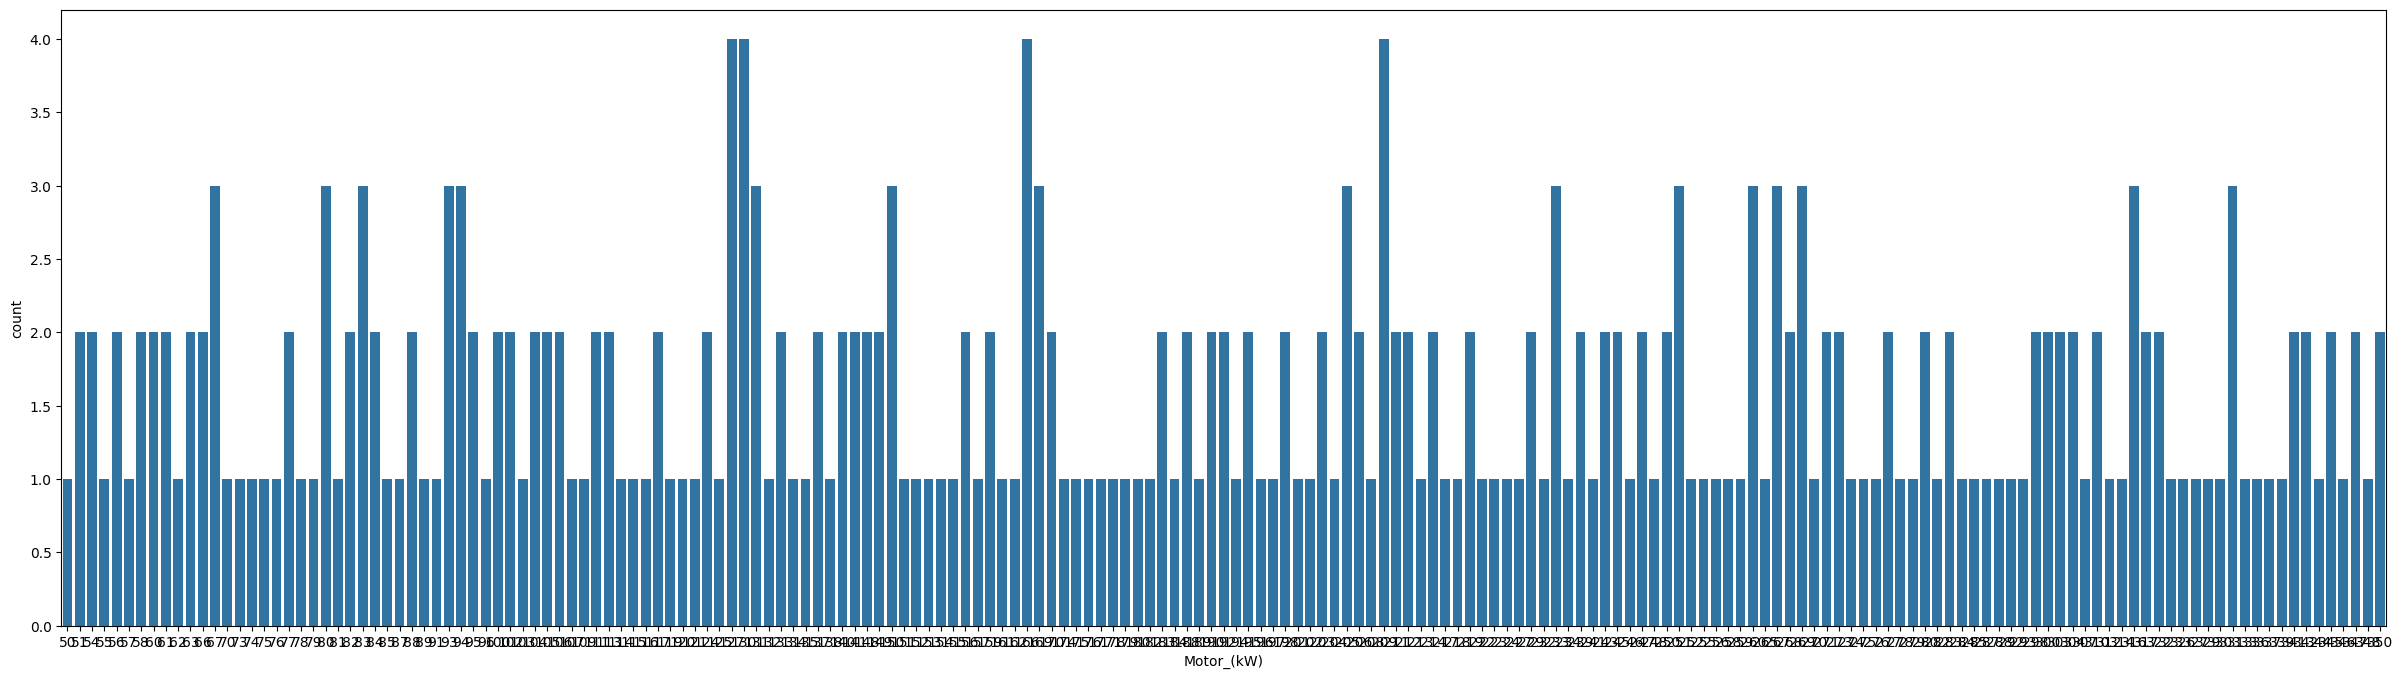

In [ ]:
plt.figure(figsize=(30, 8))
sns.countplot(x=df["Motor_(kW)"])

plt.show()

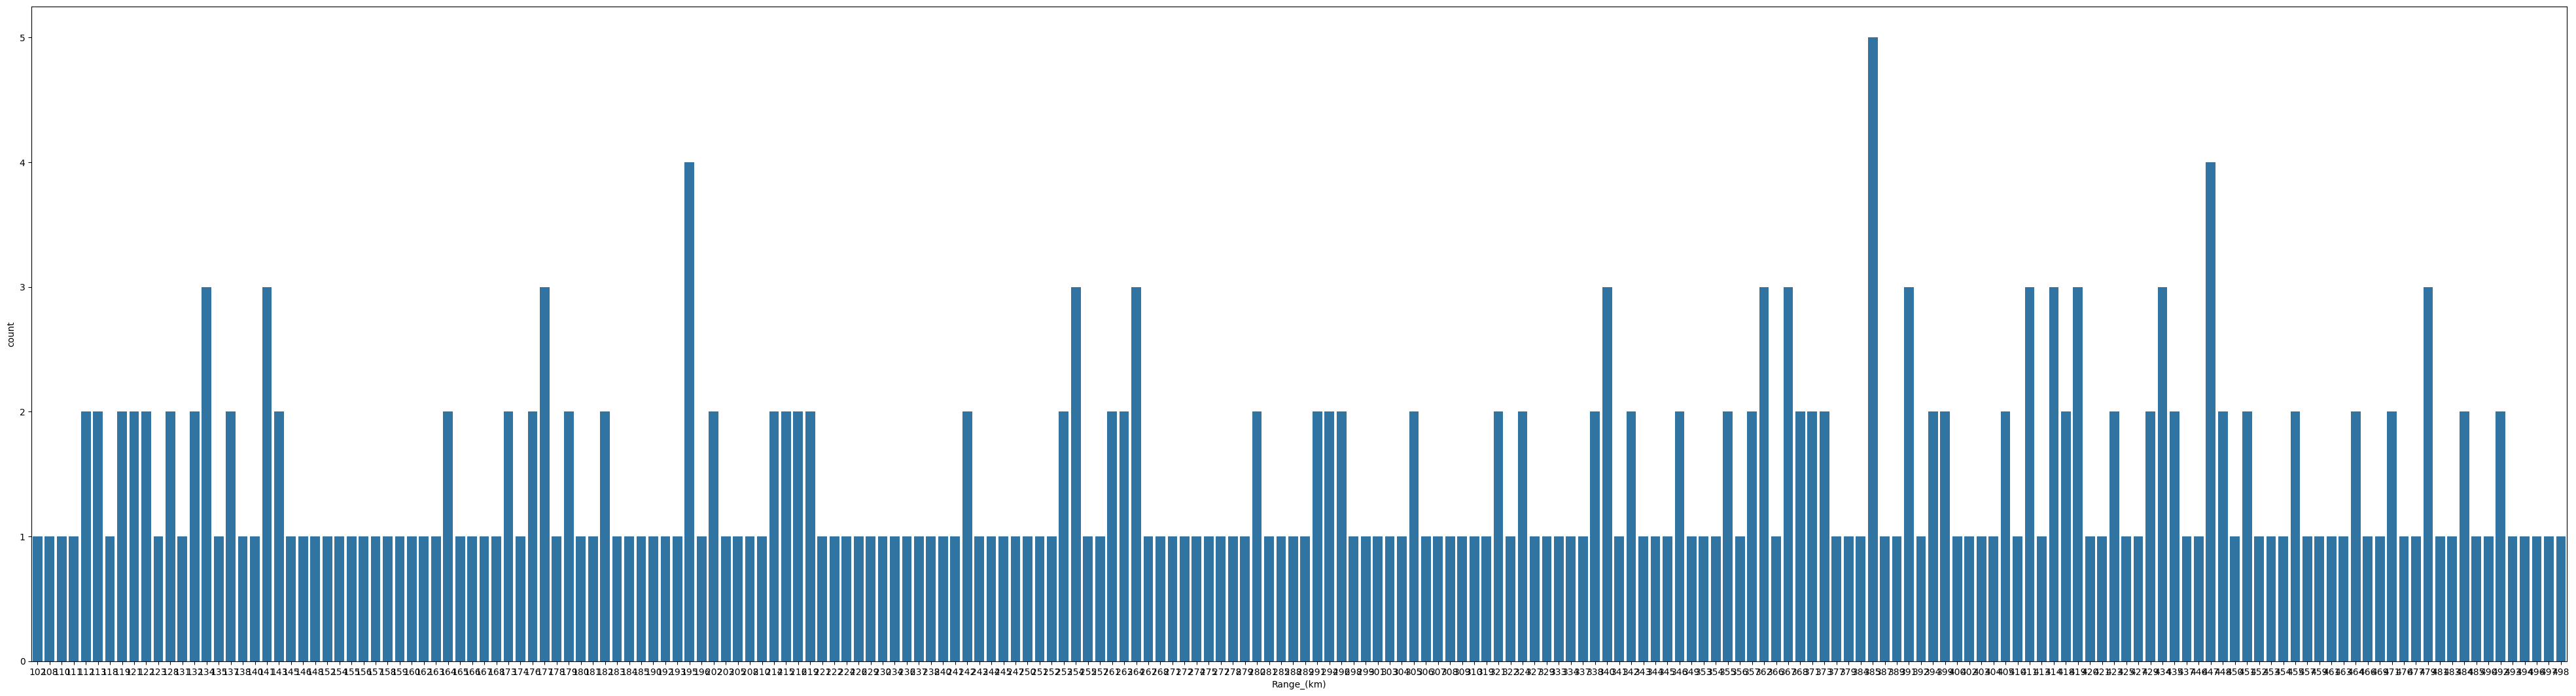

In [ ]:
plt.figure(figsize=(50, 13))
sns.countplot(x=df["Range_(km)"])
plt.show()

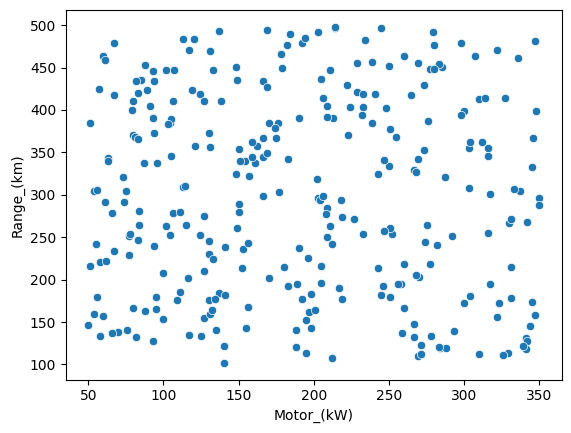

In [ ]:
sns.scatterplot(x=df["Motor_(kW)"],y=df["Range_(km)"])
plt.show()


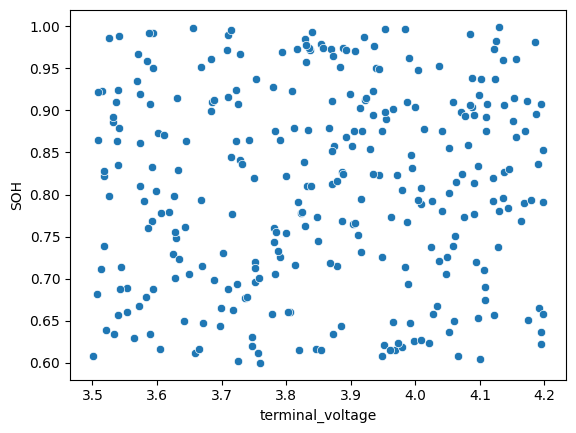

In [ ]:
sns.scatterplot(x=df["terminal_voltage"],y=df["SOH"])
plt.show()

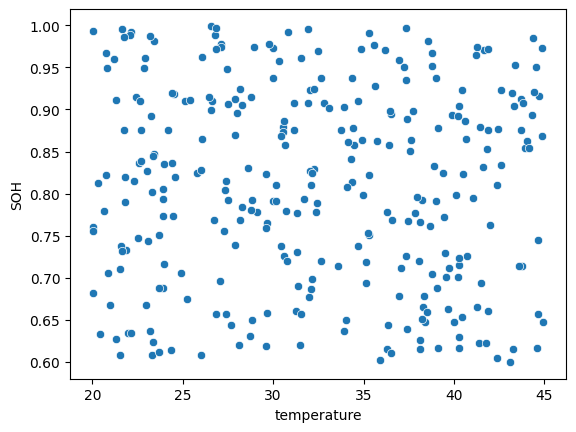

In [ ]:
sns.scatterplot(x=df["temperature"],y=df["SOH"])
plt.show()

In [ ]:
df.isnull().sum()

,0
Model_Year,0
Make,0
Model,0
Vehicle_Class,0
Motor_(kW),0
Transmission,0
Fuel_Type,0
Range_(km),0
terminal_voltage,0
terminal_current,0


In [ ]:
df['terminal_voltage'].skew()

np.float64(-0.0798229254332285)

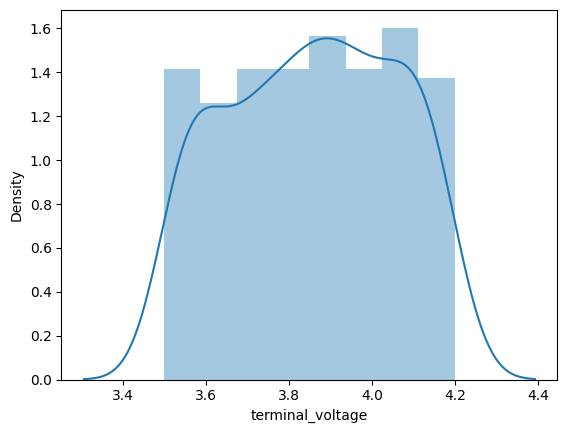

In [ ]:
sns.distplot(df['terminal_voltage'])
plt.show()

In [ ]:
df['temperature'].skew()

np.float64(-0.005009275557688713)

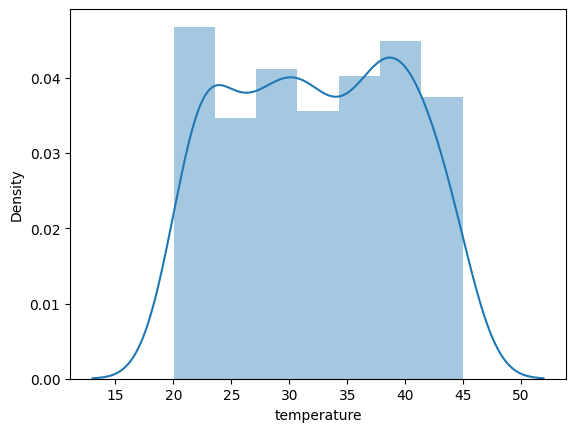

In [ ]:
sns.distplot(df['temperature'])
plt.show()

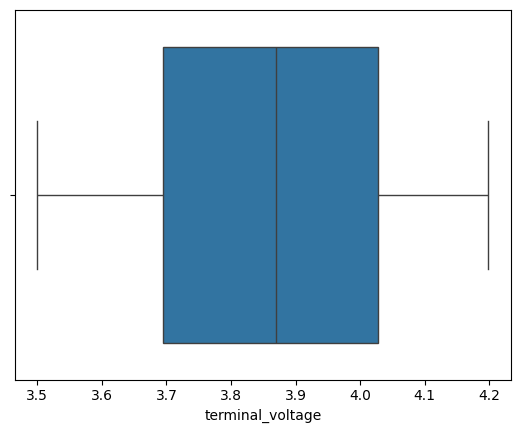

In [ ]:
sns.boxplot(x=df['terminal_voltage'])
plt.show()

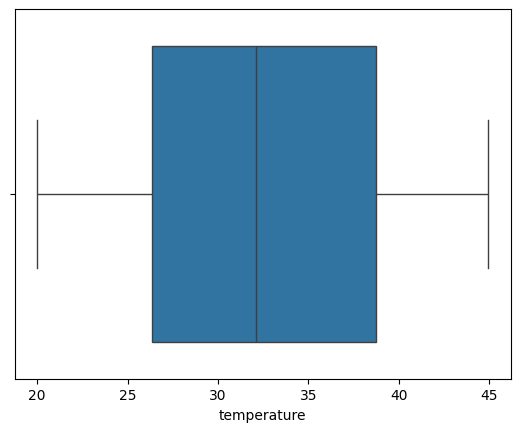

In [ ]:
sns.boxplot(x=df['temperature'])
plt.show()

In [ ]:
df=df.drop(columns=["Model_Year","Fuel_Type","Transmission",'Model','cycle'])
df

,Make,Vehicle_Class,Motor_(kW),Range_(km),terminal_voltage,terminal_current,temperature,charge_current,charge_voltage,time,capacity,SOH
0,Volkswagen,SUV: Small,102,447,3.832652,-2.293314,32.101563,0.0235,4.009,412.429,1.619294,0.810325
1,Volkswagen,SUV: Small,284,119,3.848976,1.281984,44.659498,0.5474,4.163,437.016,1.700050,0.745218
2,Nissan,Subcompact,130,176,3.525474,-2.209174,40.112061,1.3117,3.330,274.804,1.901334,0.798493
3,Volvo,Mid-size,54,304,3.717614,2.276002,39.693230,0.1610,3.741,708.535,1.919843,0.662463
4,Mitsubishi,Compact,192,177,3.818936,0.204734,30.015846,1.3009,4.088,816.811,1.619550,0.790951
...,...,...,...,...,...,...,...,...,...,...,...,...
295,Volkswagen,Mid-size,271,123,3.532419,1.080998,40.244766,0.8560,2.667,353.502,1.467555,0.892067
296,Ford,Compact,177,303,3.642742,0.411827,38.696516,0.1512,3.687,322.581,1.907499,0.761031
297,Nissan,Mid-size,166,299,4.198508,-2.443959,27.415787,1.8283,3.329,900.701,1.756749,0.657571
298,Volkswagen,Compact,124,253,4.110210,-0.860636,24.193346,0.0971,3.177,523.489,1.605553,0.875416


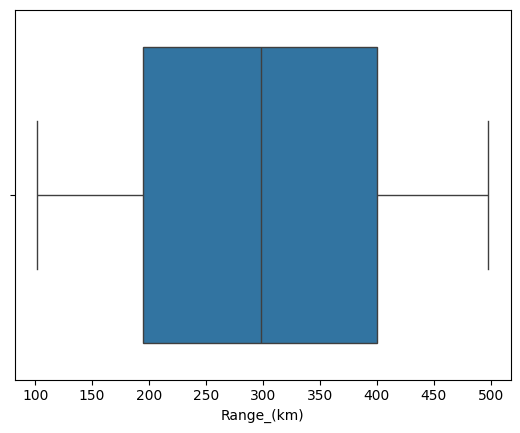

In [ ]:
sns.boxplot(x=df['Range_(km)'])
plt.show()

In [ ]:
x = df.drop(columns=['SOH'])
y = df['SOH']


In [ ]:
x

,Make,Vehicle_Class,Motor_(kW),Range_(km),terminal_voltage,terminal_current,temperature,charge_current,charge_voltage,time,capacity
0,Volkswagen,SUV: Small,102,447,3.832652,-2.293314,32.101563,0.0235,4.009,412.429,1.619294
1,Volkswagen,SUV: Small,284,119,3.848976,1.281984,44.659498,0.5474,4.163,437.016,1.700050
2,Nissan,Subcompact,130,176,3.525474,-2.209174,40.112061,1.3117,3.330,274.804,1.901334
3,Volvo,Mid-size,54,304,3.717614,2.276002,39.693230,0.1610,3.741,708.535,1.919843
4,Mitsubishi,Compact,192,177,3.818936,0.204734,30.015846,1.3009,4.088,816.811,1.619550
...,...,...,...,...,...,...,...,...,...,...,...
295,Volkswagen,Mid-size,271,123,3.532419,1.080998,40.244766,0.8560,2.667,353.502,1.467555
296,Ford,Compact,177,303,3.642742,0.411827,38.696516,0.1512,3.687,322.581,1.907499
297,Nissan,Mid-size,166,299,4.198508,-2.443959,27.415787,1.8283,3.329,900.701,1.756749
298,Volkswagen,Compact,124,253,4.110210,-0.860636,24.193346,0.0971,3.177,523.489,1.605553


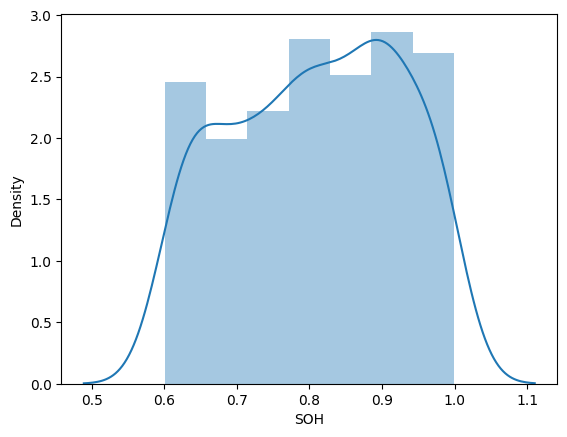

In [ ]:

sns.distplot(df['SOH'])
plt.show()

In [ ]:
df['SOH'].skew()

np.float64(-0.13257129360287764)

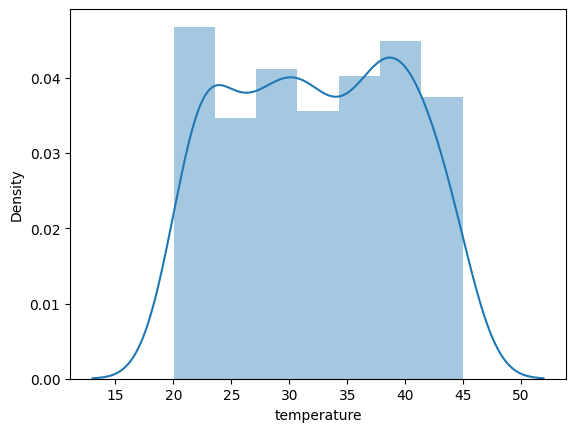

In [ ]:

sns.distplot(df['temperature'])
plt.show()

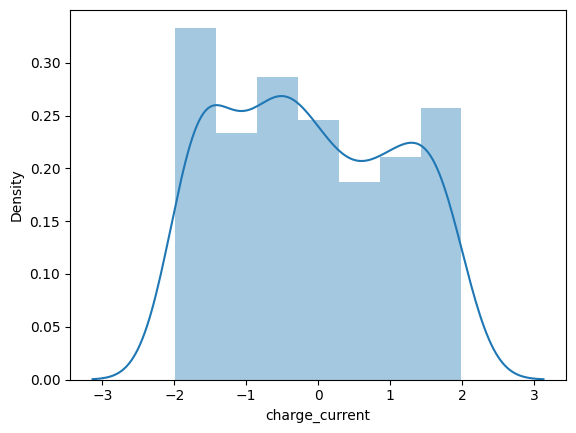

In [ ]:
sns.distplot(df['charge_current'])
plt.show()

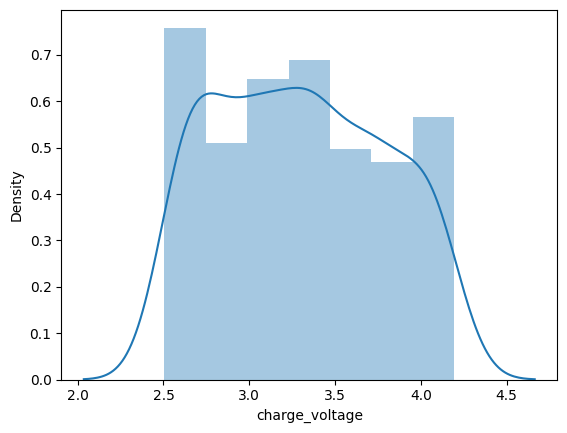

In [ ]:
sns.distplot(df['charge_voltage'])
plt.show()

In [ ]:
y=df['SOH']
y

,SOH
0,0.810325
1,0.745218
2,0.798493
3,0.662463
4,0.790951
...,...
295,0.892067
296,0.761031
297,0.657571
298,0.875416


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=100)


In [ ]:
x_test.to_csv(r'/content/EV_Similar_Dataset project.xlsx', index=False)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((240, 11), (60, 11), (240,), (60,))

In [ ]:
x_test

,Make,Vehicle_Class,Motor_(kW),Range_(km),terminal_voltage,terminal_current,temperature,charge_current,charge_voltage,time,capacity
222,Volkswagen,Compact,196,226,3.508365,-1.450091,26.081131,0.7906,2.642,965.139,1.212020
139,Volkswagen,Compact,189,195,3.943308,1.257281,20.837427,-0.1298,3.629,613.576,1.778469
216,Mitsubishi,Mid-size,50,146,3.888294,1.994166,32.129907,-1.8812,3.892,941.131,1.612054
201,Tesla,Mid-size,243,214,4.075599,-2.171717,24.468181,-1.7755,2.519,621.731,1.641646
249,Volvo,SUV: Small,190,391,4.052794,-0.631072,23.294078,-0.8766,2.944,617.264,1.392737
134,Ford,Mid-size,288,119,4.037028,-0.008989,43.376602,-1.1706,3.544,914.075,1.775266
128,Ford,Mid-size,96,338,3.629822,1.485174,22.551922,1.6308,3.296,522.736,1.397379
88,Nissan,Subcompact,77,251,3.539320,1.038196,32.234347,1.6621,3.686,408.431,1.838631
27,Tesla,Subcompact,277,448,4.190541,0.247215,22.582446,-0.9869,3.764,323.060,1.300100
288,Volvo,Subcompact,104,253,3.633676,-0.170734,40.279060,-1.9125,2.614,217.562,1.869439


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x_test['Make']=le.fit_transform(x_test['Make'])
x_train['Make']=le.fit_transform(x_train['Make'])
x_test['Vehicle_Class']=le.fit_transform(x_test['Vehicle_Class'])
x_train['Vehicle_Class']=le.fit_transform(x_train['Vehicle_Class'])

In [ ]:
x_test

,Make,Vehicle_Class,Motor_(kW),Range_(km),terminal_voltage,terminal_current,temperature,charge_current,charge_voltage,time,capacity
222,4,0,196,226,3.508365,-1.450091,26.081131,0.7906,2.642,965.139,1.212020
139,4,0,189,195,3.943308,1.257281,20.837427,-0.1298,3.629,613.576,1.778469
216,1,1,50,146,3.888294,1.994166,32.129907,-1.8812,3.892,941.131,1.612054
201,3,1,243,214,4.075599,-2.171717,24.468181,-1.7755,2.519,621.731,1.641646
249,5,2,190,391,4.052794,-0.631072,23.294078,-0.8766,2.944,617.264,1.392737
134,0,1,288,119,4.037028,-0.008989,43.376602,-1.1706,3.544,914.075,1.775266
128,0,1,96,338,3.629822,1.485174,22.551922,1.6308,3.296,522.736,1.397379
88,2,3,77,251,3.539320,1.038196,32.234347,1.6621,3.686,408.431,1.838631
27,3,3,277,448,4.190541,0.247215,22.582446,-0.9869,3.764,323.060,1.300100
288,5,3,104,253,3.633676,-0.170734,40.279060,-1.9125,2.614,217.562,1.869439


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
regressor=RandomForestRegressor(n_estimators=180)

#fit the model
%time regressor.fit(x_train,y_train)

CPU times: user 680 ms, sys: 901 µs, total: 681 ms
Wall time: 687 ms


RandomForestRegressor(n_estimators=180)

In [ ]:
# Save the model to a file
with open(r'/content/EV_Similar_Dataset project.xlsx', 'wb') as f:
    pickle.dump(regressor, f)

In [ ]:
#create the predict model
y_pred=regressor.predict(x_test)

In [ ]:
from sklearn import metrics
rf_r2=metrics.r2_score(y_test, y_pred)
rf_r2

-0.14255152731086063

In [ ]:
from sklearn import metrics
print('The accuracy score..',regressor.score(x_train,y_train)*100)
# Model Evaluation
print('R^2:', metrics.r2_score(y_test, y_pred))
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_test, y_pred))*(len(y_test)-1)/(len(y_test)-x_train.shape[1]-1))
print('MAE:',metrics.mean_absolute_error(y_test, y_pred))
print('MSE:',metrics.mean_squared_error(y_test, y_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

The accuracy score.. 85.76938840850656
R^2: -0.14255152731086063
Adjusted R^2: -0.40438625231959957
MAE: 0.09115217749999993
MSE: 0.011926990595330053
RMSE: 0.10921076226878948


In [ ]:
import numpy as np
rf_compare = pd.DataFrame({'Real Values':y_test, 'Predicted Values': y_pred})
rf_compare.head()


,Real Values,Predicted Values
222,0.864883,0.781638
139,0.949144,0.786795
216,0.824551,0.837487
201,0.773110,0.767653
249,0.802321,0.845999


xg boost


In [ ]:
import xgboost as xgb
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=180,max_depth=100)

#fit the model
%time xgb.fit(x_train,y_train)
# Save the model to a file
with open(r'/content/EV_Similar_Dataset project.xlsx', 'wb') as f:
    pickle.dump(xgb, f)
#create the predict model
y_pred1=xgb.predict(x_test)


CPU times: user 448 ms, sys: 823 µs, total: 449 ms
Wall time: 232 ms


In [ ]:
from sklearn import metrics
xgb_r2=metrics.r2_score(y_test, y_pred1)

In [ ]:
from sklearn import metrics
print('The accuracy score..',xgb.score(x_train,y_train)*100)
# Model Evaluation
print('R^2:', metrics.r2_score(y_test, y_pred1))
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_test, y_pred1))*(len(y_test)-1)/(len(y_test)-x_train.shape[1]-1))
print('MAE:',metrics.mean_absolute_error(y_test, y_pred1))
print('MSE:',metrics.mean_squared_error(y_test, y_pred1))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test, y_pred1)))

The accuracy score.. 99.99809955372747
R^2: -0.6176930815715935
Adjusted R^2: -0.9884144127650838
MAE: 0.10282331742229461
MSE: 0.016886949698843124
RMSE: 0.1299497968403303


linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
linear_regressor = LinearRegression()
#fit the model
%time linear_regressor.fit(x_train,y_train)
with open(r'/content/EV_Similar_Dataset project.xlsx', 'wb') as f:
    pickle.dump(linear_regressor, f)
#create the predict model
y_pred2=linear_regressor.predict(x_test)


CPU times: user 3 ms, sys: 0 ns, total: 3 ms
Wall time: 2.9 ms


In [ ]:
# Print the coefficients and intercept
print("Coefficients:", linear_regressor.coef_)
print("Intercept:", linear_regressor.intercept_)


Coefficients: [ 1.42635541e-03 -9.76951096e-03  1.13563728e-04  1.08817920e-04
  4.55990724e-02 -2.88166340e-03 -5.41910023e-04 -3.59261906e-03
 -5.95769997e-03 -3.26505015e-05 -3.28731479e-02]
Intercept: 0.69625387274202


In [ ]:
from sklearn import metrics
print('The accuracy score..',linear_regressor.score(x_train,y_train)*100)
# Model Evaluation
print('R^2:', metrics.r2_score(y_test, y_pred2))
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_test, y_pred2))*(len(y_test)-1)/(len(y_test)-x_train.shape[1]-1))
print('MAE:',metrics.mean_absolute_error(y_test, y_pred2))
print('MSE:',metrics.mean_squared_error(y_test, y_pred2))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test, y_pred2)))

The accuracy score.. 3.990661702630094
R^2: -0.2720634220699749
Adjusted R^2: -0.5635779562943444
MAE: 0.09687940999549993
MSE: 0.013278953385499306
RMSE: 0.11523434117267


In [ ]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge regression model with regularization
ridge_regressor = Ridge(alpha=0.1)  # You can adjust the alpha parameter for regularization strength
%time ridge_regressor.fit(x_train, y_train)
with open(r'/content/EV_Similar_Dataset project.xlsx', 'wb') as f:
    pickle.dump(ridge_regressor, f)

CPU times: user 4.78 ms, sys: 0 ns, total: 4.78 ms
Wall time: 13.6 ms


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
decision_tree_regressor = DecisionTreeRegressor()
%time decision_tree_regressor.fit(x_train, y_train)
with open(r'/content/EV_Similar_Dataset project.xlsx', 'wb') as f:
    pickle.dump(decision_tree_regressor, f)

CPU times: user 10.1 ms, sys: 0 ns, total: 10.1 ms
Wall time: 11.6 ms


In [ ]:
#create the predict model
y_pred5=ridge_regressor.predict(x_test)

In [ ]:
from sklearn import metrics
print('The accuracy score..',decision_tree_regressor.score(x_train,y_train)*100)
# Model Evaluation
print('R^2:', metrics.r2_score(y_test, y_pred5))
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_test, y_pred5))*(len(y_test)-1)/(len(y_test)-x_train.shape[1]-1))
print('MAE:',metrics.mean_absolute_error(y_test, y_pred5))
print('MSE:',metrics.mean_squared_error(y_test, y_pred5))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test, y_pred5)))

The accuracy score.. 100.0
R^2: -0.2714894245599859
Adjusted R^2: -0.5628724176883162
MAE: 0.09686778753451636
MSE: 0.01327296147814131
RMSE: 0.11520833944702662


decison tree and grid

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import time

# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],   # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]      # Minimum number of samples required to be at a leaf node
}

# Initialize the Decision Tree Regressor
decision_tree_regressor = DecisionTreeRegressor(random_state=42)

# Initialize GridSearchCV with the defined parameter grid and model
grid_search = GridSearchCV(decision_tree_regressor, param_grid, cv=5, scoring='neg_mean_squared_error')

# Perform the grid search
start_time = time.time()
grid_search.fit(x_train, y_train)

end_time = time.time()

# Print the best parameters and the time taken for grid search
print("Best Parameters:", grid_search.best_params_)
print("Time taken for grid search: {:.2f} seconds".format(end_time - start_time))


Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Time taken for grid search: 2.21 seconds


In [ ]:
# Set the best parameters found from GridSearchCV
best_params = {
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}
# Initialize the Decision Tree Regressor with the best parameters
final_decision_tree_regressor = DecisionTreeRegressor(**best_params, random_state=42)

# Train the final model on the entire training data
final_decision_tree_regressor.fit(x_train, y_train)

with open(r'/content/EV_Similar_Dataset project.xlsx', 'wb') as f:
    pickle.dump(final_decision_tree_regressor, f)

In [ ]:
# Set the best parameters found from GridSearchCV
best_params = {
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}
# Initialize the Decision Tree Regressor with the best parameters
final_decision_tree_regressor = DecisionTreeRegressor(**best_params, random_state=42)

# Train the final model on the entire training data
final_decision_tree_regressor.fit(x_train, y_train)

with open(r'/content/EV_Similar_Dataset project.xlsx', 'wb') as f:
    pickle.dump(final_decision_tree_regressor, f)

In [ ]:
y_pred

array([0.78163789, 0.78679459, 0.83748707, 0.76765316, 0.84599892,
       0.78603176, 0.82165597, 0.79409526, 0.8405387 , 0.82014839,
       0.83238577, 0.76200019, 0.82054425, 0.81155368, 0.84086796,
       0.80671384, 0.74824119, 0.81480577, 0.82582764, 0.80183416,
       0.84151528, 0.8224333 , 0.8404798 , 0.85734029, 0.81437973,
       0.84148497, 0.78334147, 0.83329012, 0.79390639, 0.81247327,
       0.80970367, 0.81985756, 0.84452605, 0.79938812, 0.82257823,
       0.786256  , 0.77748368, 0.82030009, 0.85768225, 0.78809513,
       0.80129735, 0.77023419, 0.85145841, 0.75682782, 0.78648685,
       0.80075156, 0.80522929, 0.85558506, 0.77846269, 0.83904695,
       0.84097938, 0.78667715, 0.79754229, 0.81571901, 0.85820318,
       0.77486839, 0.84906765, 0.81803624, 0.78385309, 0.76955517])

In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
mae

0.09115217749999993

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mse

0.011926990595330053

In [ ]:
from sklearn.metrics import r2_score
r2_dt = r2_score(y_test, y_pred)
r2_dt

-0.14255152731086063

In [ ]:
n = len(x_test)  # Number of samples in the test set
p = x_test.shape[1]  # Number of features
adjusted_r2 = 1 - ((1 - r2_dt) * (n - 1) / (n - p - 1))
adjusted_r2

-0.40438625231959957

In [ ]:
import numpy as np
rf_compare = pd.DataFrame({'Real Values':y_test, 'Predicted Values': y_pred})
rf_compare.head(10)

,Real Values,Predicted Values
222,0.864883,0.781638
139,0.949144,0.786795
216,0.824551,0.837487
201,0.773110,0.767653
249,0.802321,0.845999
134,0.953165,0.786032
128,0.747840,0.821656
88,0.924517,0.794095
27,0.836831,0.840539
288,0.723680,0.820148


In [ ]:
from sklearn.ensemble import VotingRegressor
# Initialize the Voting Regressor with a list of base regressors
voting_reg = VotingRegressor(estimators=[('xgb', xgb), ('rf', regressor)])

# Train the Voting Regressor
voting_reg.fit(x_train, y_train)

with open(r'C:\Users\Akash\Music\EVBATTERY\EVBATTERY\CODE\BACKEND\voting_model.pkl', 'wb') as f:
    pickle.dump(voting_reg, f)

# Make predictions
y_pred_ = voting_reg.predict(x_test)

# Evaluate the performance of the Voting Regressor
mse = mean_squared_error(y_test, y_pred_)
print("Voting Regressor Mean Squared Error:", mse)

Voting Regressor Mean Squared Error: 0.01391367969139051


In [ ]:
y_pred_

array([0.77325612, 0.77430074, 0.85108214, 0.75313704, 0.81533496,
       0.80656737, 0.81934831, 0.76922631, 0.84193069, 0.76903272,
       0.83444166, 0.76443277, 0.77103039, 0.76446039, 0.8532548 ,
       0.79826226, 0.73570946, 0.86736671, 0.79947582, 0.80472116,
       0.85092826, 0.85265926, 0.77102402, 0.88021708, 0.79121069,
       0.84278481, 0.77460266, 0.84217101, 0.77469937, 0.82006997,
       0.76577379, 0.78867006, 0.87194162, 0.80173752, 0.79995694,
       0.83241941, 0.71529464, 0.85206739, 0.87957366, 0.79443023,
       0.82291681, 0.72675984, 0.82249112, 0.69975409, 0.7261601 ,
       0.83579776, 0.82625046, 0.85952915, 0.72864635, 0.83281598,
       0.87006827, 0.79141213, 0.78632783, 0.81552481, 0.82240298,
       0.71764697, 0.85674217, 0.77471912, 0.7717943 , 0.75430696])

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_)
r2

-0.33286731928310154

In [ ]:
import numpy as np
rf_compare = pd.DataFrame({'Real Values':y_test, 'Predicted Values': y_pred_})
rf_compare.head(10)

,Real Values,Predicted Values
222,0.864883,0.773256
139,0.949144,0.774301
216,0.824551,0.851082
201,0.773110,0.753137
249,0.802321,0.815335
134,0.953165,0.806567
128,0.747840,0.819348
88,0.924517,0.769226
27,0.836831,0.841931
288,0.723680,0.769033


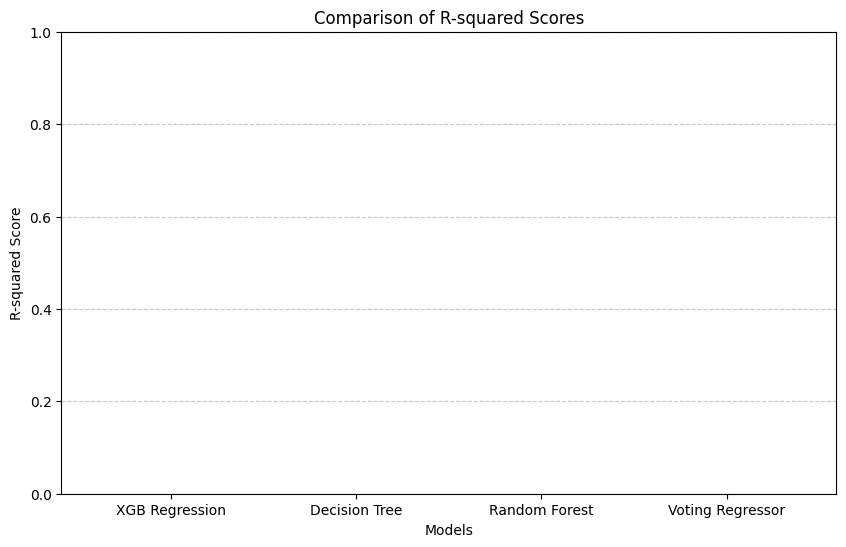

In [ ]:
import matplotlib.pyplot as plt

# R-squared scores of the models
models = ['XGB Regression', 'Decision Tree', 'Random Forest', 'Voting Regressor']
r2_scores = [xgb_r2, r2_dt, rf_r2, r2]  # Replace with your actual R-squared scores

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(models, r2_scores, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Models')
plt.ylabel('R-squared Score')
plt.title('Comparison of R-squared Scores')
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
